# FashionStyle14 Complete Dataset Analysis & Splitting

## Overview
This notebook provides a comprehensive analysis of the FashionStyle14 dataset with proper data discovery, EDA, and stratified splitting.

## Workflow:
1. **Dataset Discovery**: Scan all images in the dataset folder and create a complete CSV
2. **Exploratory Data Analysis**: Analyze the complete dataset
3. **Stratified Splitting**: Create balanced train/val/test splits addressing class imbalance

## Project Goals
Our multi-modal framework aims to:
1. Use LLM-generated captions for rich textual data
2. Employ CLIP visual encoder and FashionBERT for feature extraction
3. Fuse visual and textual features for multi-label classification
4. Develop accurate and scalable fashion style identification


## 1. Setup and Imports


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from PIL import Image
import warnings
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import json

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")
print(f"Current working directory: {os.getcwd()}")


Libraries imported successfully!
Current working directory: c:\tmp\FashionStyle14_v1


## 2. Dataset Discovery - Create Complete CSV


In [5]:
def discover_all_images(dataset_path='dataset'):
    """
    Discover all images in the dataset folder and create a complete dataframe
    """
    print(f"Scanning dataset folder: {dataset_path}")
    
    all_images = []
    supported_formats = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    
    # Get all style folders
    style_folders = [f for f in os.listdir(dataset_path) 
                    if os.path.isdir(os.path.join(dataset_path, f))]
    
    print(f"Found {len(style_folders)} style categories: {sorted(style_folders)}")
    
    for style_folder in sorted(style_folders):
        style_path = os.path.join(dataset_path, style_folder)
        image_count = 0
        
        # Get all image files in this style folder
        for image_file in os.listdir(style_path):
            if image_file.lower().endswith(supported_formats):
                image_path = os.path.join(style_path, image_file)
                all_images.append({
                    'image_path': image_path,
                    'style': style_folder,
                    'filename': image_file
                })
                image_count += 1
        
        print(f"  {style_folder}: {image_count} images")
    
    df = pd.DataFrame(all_images)
    print(f"\nTotal images discovered: {len(df)}")
    return df

# Discover all images
complete_dataset = discover_all_images('dataset')


Scanning dataset folder: dataset
Found 14 style categories: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
  conservative: 918 images
  dressy: 898 images
  ethnic: 859 images
  fairy: 955 images
  feminine: 806 images
  gal: 954 images
  girlish: 1105 images
  kireime-casual: 1054 images
  lolita: 1063 images
  mode: 1061 images
  natural: 861 images
  retro: 845 images
  rock: 810 images
  street: 1022 images

Total images discovered: 13211


In [6]:
# Display basic information about the complete dataset
print("Complete Dataset Information:")
print(f"Shape: {complete_dataset.shape}")
print(f"Columns: {list(complete_dataset.columns)}")
print(f"\nFirst 5 rows:")
print(complete_dataset.head())

print(f"\nStyle distribution:")
style_counts = complete_dataset['style'].value_counts().sort_index()
print(style_counts)

# Save the complete dataset to CSV
complete_dataset[['image_path']].to_csv('complete_dataset.csv', index=False, header=False)
print(f"\nComplete dataset saved to 'complete_dataset.csv'")
print(f"Total images: {len(complete_dataset)}")


Complete Dataset Information:
Shape: (13211, 3)
Columns: ['image_path', 'style', 'filename']

First 5 rows:
                                 image_path         style             filename
0           dataset\conservative\00-254.jpg  conservative           00-254.jpg
1           dataset\conservative\00-795.jpg  conservative           00-795.jpg
2      dataset\conservative\00000274_02.jpg  conservative      00000274_02.jpg
3   dataset\conservative\00100_05_00938.jpg  conservative   00100_05_00938.jpg
4  dataset\conservative\001969733001_12.jpg  conservative  001969733001_12.jpg

Style distribution:
style
conservative       918
dressy             898
ethnic             859
fairy              955
feminine           806
gal                954
girlish           1105
kireime-casual    1054
lolita            1063
mode              1061
natural            861
retro              845
rock               810
street            1022
Name: count, dtype: int64

Complete dataset saved to 'complete_datase

## 3. Exploratory Data Analysis


In [7]:
# Class distribution analysis
print("=" * 60)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)

style_distribution = complete_dataset['style'].value_counts().sort_index()
print(f"Total classes: {len(style_distribution)}")
print(f"Total images: {len(complete_dataset)}")
print(f"\nClass distribution:")
print(style_distribution)

# Calculate statistics
print(f"\nStatistics:")
print(f"Mean samples per class: {style_distribution.mean():.1f}")
print(f"Std samples per class: {style_distribution.std():.1f}")
print(f"Min samples per class: {style_distribution.min()}")
print(f"Max samples per class: {style_distribution.max()}")
print(f"Class imbalance ratio: {style_distribution.max() / style_distribution.min():.2f}:1")

# Identify imbalanced classes
mean_samples = style_distribution.mean()
imbalanced_classes = style_distribution[style_distribution < mean_samples * 0.8]
overrepresented_classes = style_distribution[style_distribution > mean_samples * 1.2]

print(f"\nImbalanced classes (< 80% of mean):")
print(imbalanced_classes)

print(f"\nOverrepresented classes (> 120% of mean):")
print(overrepresented_classes)


CLASS DISTRIBUTION ANALYSIS
Total classes: 14
Total images: 13211

Class distribution:
style
conservative       918
dressy             898
ethnic             859
fairy              955
feminine           806
gal                954
girlish           1105
kireime-casual    1054
lolita            1063
mode              1061
natural            861
retro              845
rock               810
street            1022
Name: count, dtype: int64

Statistics:
Mean samples per class: 943.6
Std samples per class: 102.2
Min samples per class: 806
Max samples per class: 1105
Class imbalance ratio: 1.37:1

Imbalanced classes (< 80% of mean):
Series([], Name: count, dtype: int64)

Overrepresented classes (> 120% of mean):
Series([], Name: count, dtype: int64)


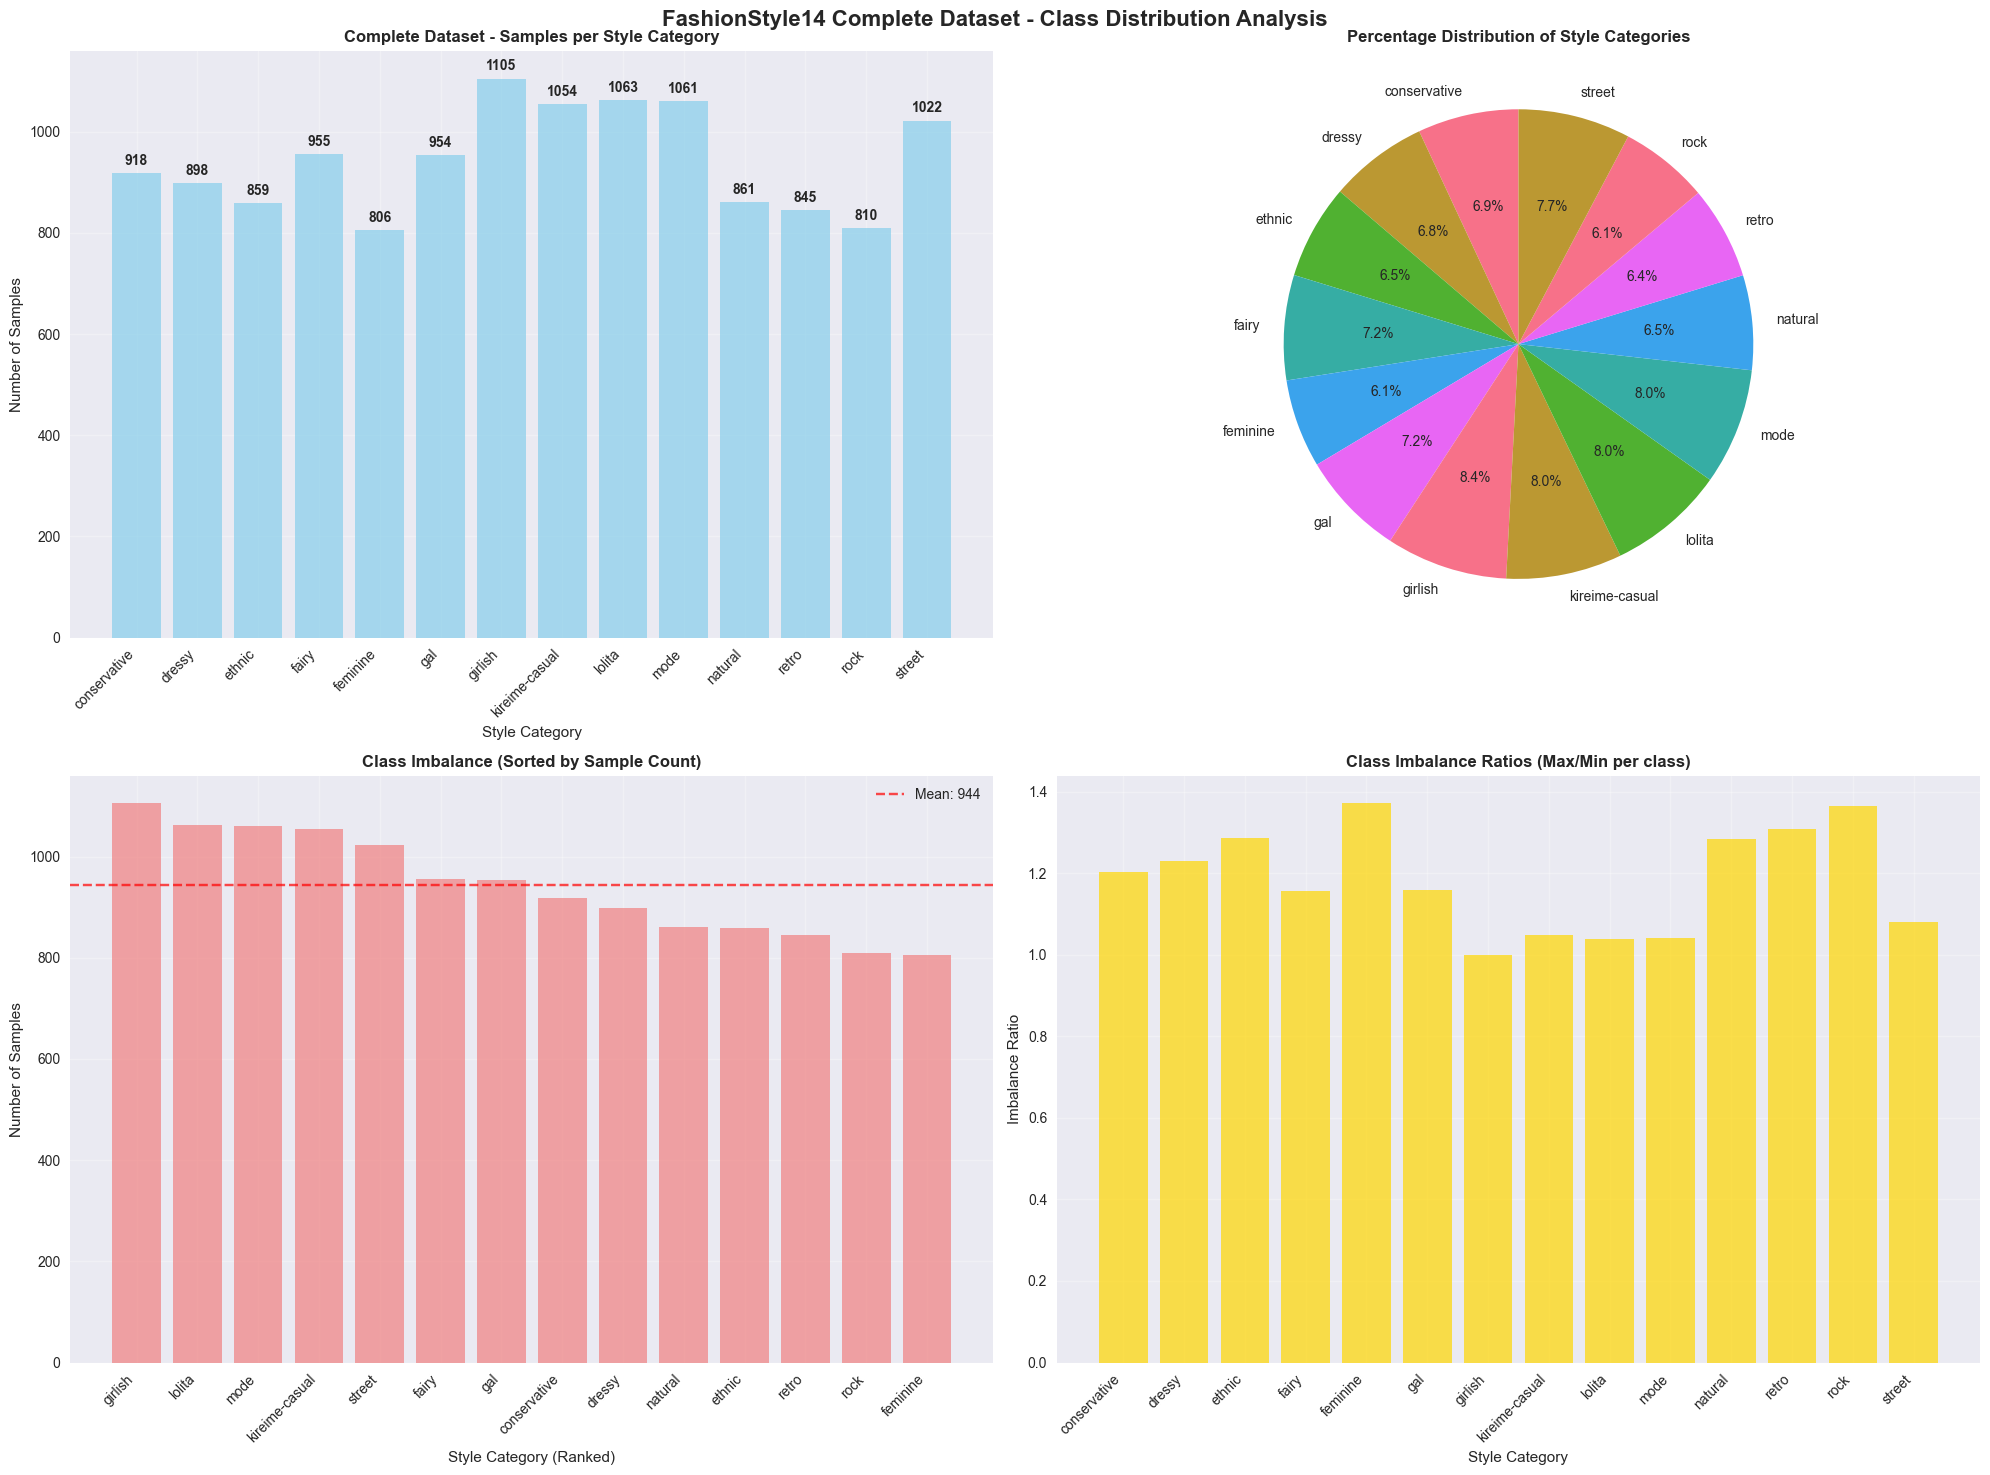

In [8]:
# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('FashionStyle14 Complete Dataset - Class Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Bar chart of class distribution
axes[0, 0].bar(range(len(style_distribution)), style_distribution.values, color='skyblue', alpha=0.7)
axes[0, 0].set_title('Complete Dataset - Samples per Style Category', fontweight='bold')
axes[0, 0].set_xlabel('Style Category')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_xticks(range(len(style_distribution)))
axes[0, 0].set_xticklabels(style_distribution.index, rotation=45, ha='right')
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(style_distribution.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Pie chart
axes[0, 1].pie(style_distribution.values, labels=style_distribution.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Percentage Distribution of Style Categories', fontweight='bold')

# 3. Sorted distribution (imbalance visualization)
sorted_dist = style_distribution.sort_values(ascending=False)
axes[1, 0].bar(range(len(sorted_dist)), sorted_dist.values, color='lightcoral', alpha=0.7)
axes[1, 0].set_title('Class Imbalance (Sorted by Sample Count)', fontweight='bold')
axes[1, 0].set_xlabel('Style Category (Ranked)')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_xticks(range(len(sorted_dist)))
axes[1, 0].set_xticklabels(sorted_dist.index, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# Add horizontal line for mean
mean_samples = style_distribution.mean()
axes[1, 0].axhline(y=mean_samples, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_samples:.0f}')
axes[1, 0].legend()

# 4. Class imbalance ratio visualization
imbalance_ratios = style_distribution.max() / style_distribution
axes[1, 1].bar(range(len(imbalance_ratios)), imbalance_ratios.values, color='gold', alpha=0.7)
axes[1, 1].set_title('Class Imbalance Ratios (Max/Min per class)', fontweight='bold')
axes[1, 1].set_xlabel('Style Category')
axes[1, 1].set_ylabel('Imbalance Ratio')
axes[1, 1].set_xticks(range(len(imbalance_ratios)))
axes[1, 1].set_xticklabels(imbalance_ratios.index, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Image Properties Analysis


In [9]:
def analyze_image_properties(df, sample_size=1000):
    """
    Analyze image properties for a sample of the dataset
    """
    print(f"Analyzing image properties (sampling {min(sample_size, len(df))} images)...")
    
    # Sample images for analysis
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    
    image_props = []
    file_sizes = []
    file_formats = []
    
    for idx, row in sample_df.iterrows():
        try:
            image_path = row['image_path']
            
            if os.path.exists(image_path):
                # Get file size
                file_size = os.path.getsize(image_path)
                file_sizes.append(file_size)
                
                # Get file format
                file_format = image_path.split('.')[-1].lower()
                file_formats.append(file_format)
                
                # Get image dimensions
                with Image.open(image_path) as img:
                    width, height = img.size
                    image_props.append({
                        'width': width,
                        'height': height,
                        'aspect_ratio': width / height,
                        'total_pixels': width * height,
                        'file_size': file_size,
                        'format': file_format,
                        'style': row['style']
                    })
            else:
                print(f"Warning: File not found: {image_path}")
                
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
    
    return pd.DataFrame(image_props), file_sizes, file_formats

# Analyze image properties
image_props_df, file_sizes, file_formats = analyze_image_properties(complete_dataset, 1000)

print(f"Successfully analyzed {len(image_props_df)} images")


Analyzing image properties (sampling 1000 images)...
Successfully analyzed 1000 images


In [10]:
# Display image properties summary
print("Image Properties Summary:")
print(f"Total images analyzed: {len(image_props_df)}")
print(f"\nDimension Statistics:")
print(f"Width - Mean: {image_props_df['width'].mean():.1f}, Std: {image_props_df['width'].std():.1f}")
print(f"Height - Mean: {image_props_df['height'].mean():.1f}, Std: {image_props_df['height'].std():.1f}")
print(f"Aspect Ratio - Mean: {image_props_df['aspect_ratio'].mean():.2f}, Std: {image_props_df['aspect_ratio'].std():.2f}")
print(f"Total Pixels - Mean: {image_props_df['total_pixels'].mean():.0f}, Std: {image_props_df['total_pixels'].std():.0f}")

print(f"\nFile Size Statistics:")
print(f"Mean: {np.mean(file_sizes) / 1024:.1f} KB, Std: {np.std(file_sizes) / 1024:.1f} KB")
print(f"Min: {np.min(file_sizes) / 1024:.1f} KB, Max: {np.max(file_sizes) / 1024:.1f} KB")

print(f"\nFile Format Distribution:")
format_counts = Counter(file_formats)
for format_type, count in format_counts.most_common():
    print(f"{format_type}: {count} ({count/len(file_formats)*100:.1f}%)")


Image Properties Summary:
Total images analyzed: 1000

Dimension Statistics:
Width - Mean: 247.6, Std: 30.4
Height - Mean: 367.7, Std: 82.9
Aspect Ratio - Mean: 0.70, Std: 0.17
Total Pixels - Mean: 90917, Std: 22097

File Size Statistics:
Mean: 34.6 KB, Std: 29.3 KB
Min: 4.6 KB, Max: 231.0 KB

File Format Distribution:
jpg: 948 (94.8%)
jpeg: 33 (3.3%)
png: 19 (1.9%)


## 5. Stratified Train/Validation/Test Splitting


In [11]:
def create_stratified_splits(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Create stratified train/validation/test splits addressing class imbalance
    """
    print(f"Creating stratified splits:")
    print(f"  Train: {train_ratio*100:.1f}%")
    print(f"  Validation: {val_ratio*100:.1f}%")
    print(f"  Test: {test_ratio*100:.1f}%")
    
    # Verify ratios sum to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1.0"
    
    # First split: train vs (val+test)
    train_df, temp_df = train_test_split(
        df, 
        test_size=(val_ratio + test_ratio), 
        stratify=df['style'], 
        random_state=random_state
    )
    
    # Second split: val vs test
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=test_ratio/(val_ratio + test_ratio), 
        stratify=temp_df['style'], 
        random_state=random_state
    )
    
    return train_df, val_df, test_df

# Create stratified splits
train_df, val_df, test_df = create_stratified_splits(complete_dataset)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(complete_dataset)*100:.1f}%)")
print(f"  Validation: {len(val_df)} ({len(val_df)/len(complete_dataset)*100:.1f}%)")
print(f"  Test: {len(test_df)} ({len(test_df)/len(complete_dataset)*100:.1f}%)")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)}")


Creating stratified splits:
  Train: 70.0%
  Validation: 15.0%
  Test: 15.0%

Split sizes:
  Train: 9247 (70.0%)
  Validation: 1982 (15.0%)
  Test: 1982 (15.0%)
  Total: 13211


In [12]:
# Analyze the new splits
def analyze_splits(train_df, val_df, test_df):
    """Analyze the distribution of classes across splits"""
    
    # Calculate class distribution for each split
    train_dist = train_df['style'].value_counts().sort_index()
    val_dist = val_df['style'].value_counts().sort_index()
    test_dist = test_df['style'].value_counts().sort_index()
    
    # Create combined distribution dataframe
    distribution_df = pd.DataFrame({
        'Train': train_dist,
        'Validation': val_dist,
        'Test': test_dist
    }).fillna(0).astype(int)
    
    distribution_df['Total'] = distribution_df.sum(axis=1)
    distribution_df['Train_Pct'] = (distribution_df['Train'] / distribution_df['Total'] * 100).round(1)
    distribution_df['Val_Pct'] = (distribution_df['Validation'] / distribution_df['Total'] * 100).round(1)
    distribution_df['Test_Pct'] = (distribution_df['Test'] / distribution_df['Total'] * 100).round(1)
    
    return distribution_df

# Analyze the new splits
split_analysis = analyze_splits(train_df, val_df, test_df)
print("Class Distribution Across New Splits:")
print(split_analysis)


Class Distribution Across New Splits:
                Train  Validation  Test  Total  Train_Pct  Val_Pct  Test_Pct
style                                                                       
conservative      643         138   137    918       70.0     15.0      14.9
dressy            629         135   134    898       70.0     15.0      14.9
ethnic            601         129   129    859       70.0     15.0      15.0
fairy             668         143   144    955       69.9     15.0      15.1
feminine          564         121   121    806       70.0     15.0      15.0
gal               668         143   143    954       70.0     15.0      15.0
girlish           773         166   166   1105       70.0     15.0      15.0
kireime-casual    738         158   158   1054       70.0     15.0      15.0
lolita            744         159   160   1063       70.0     15.0      15.1
mode              743         159   159   1061       70.0     15.0      15.0
natural           603         129   12

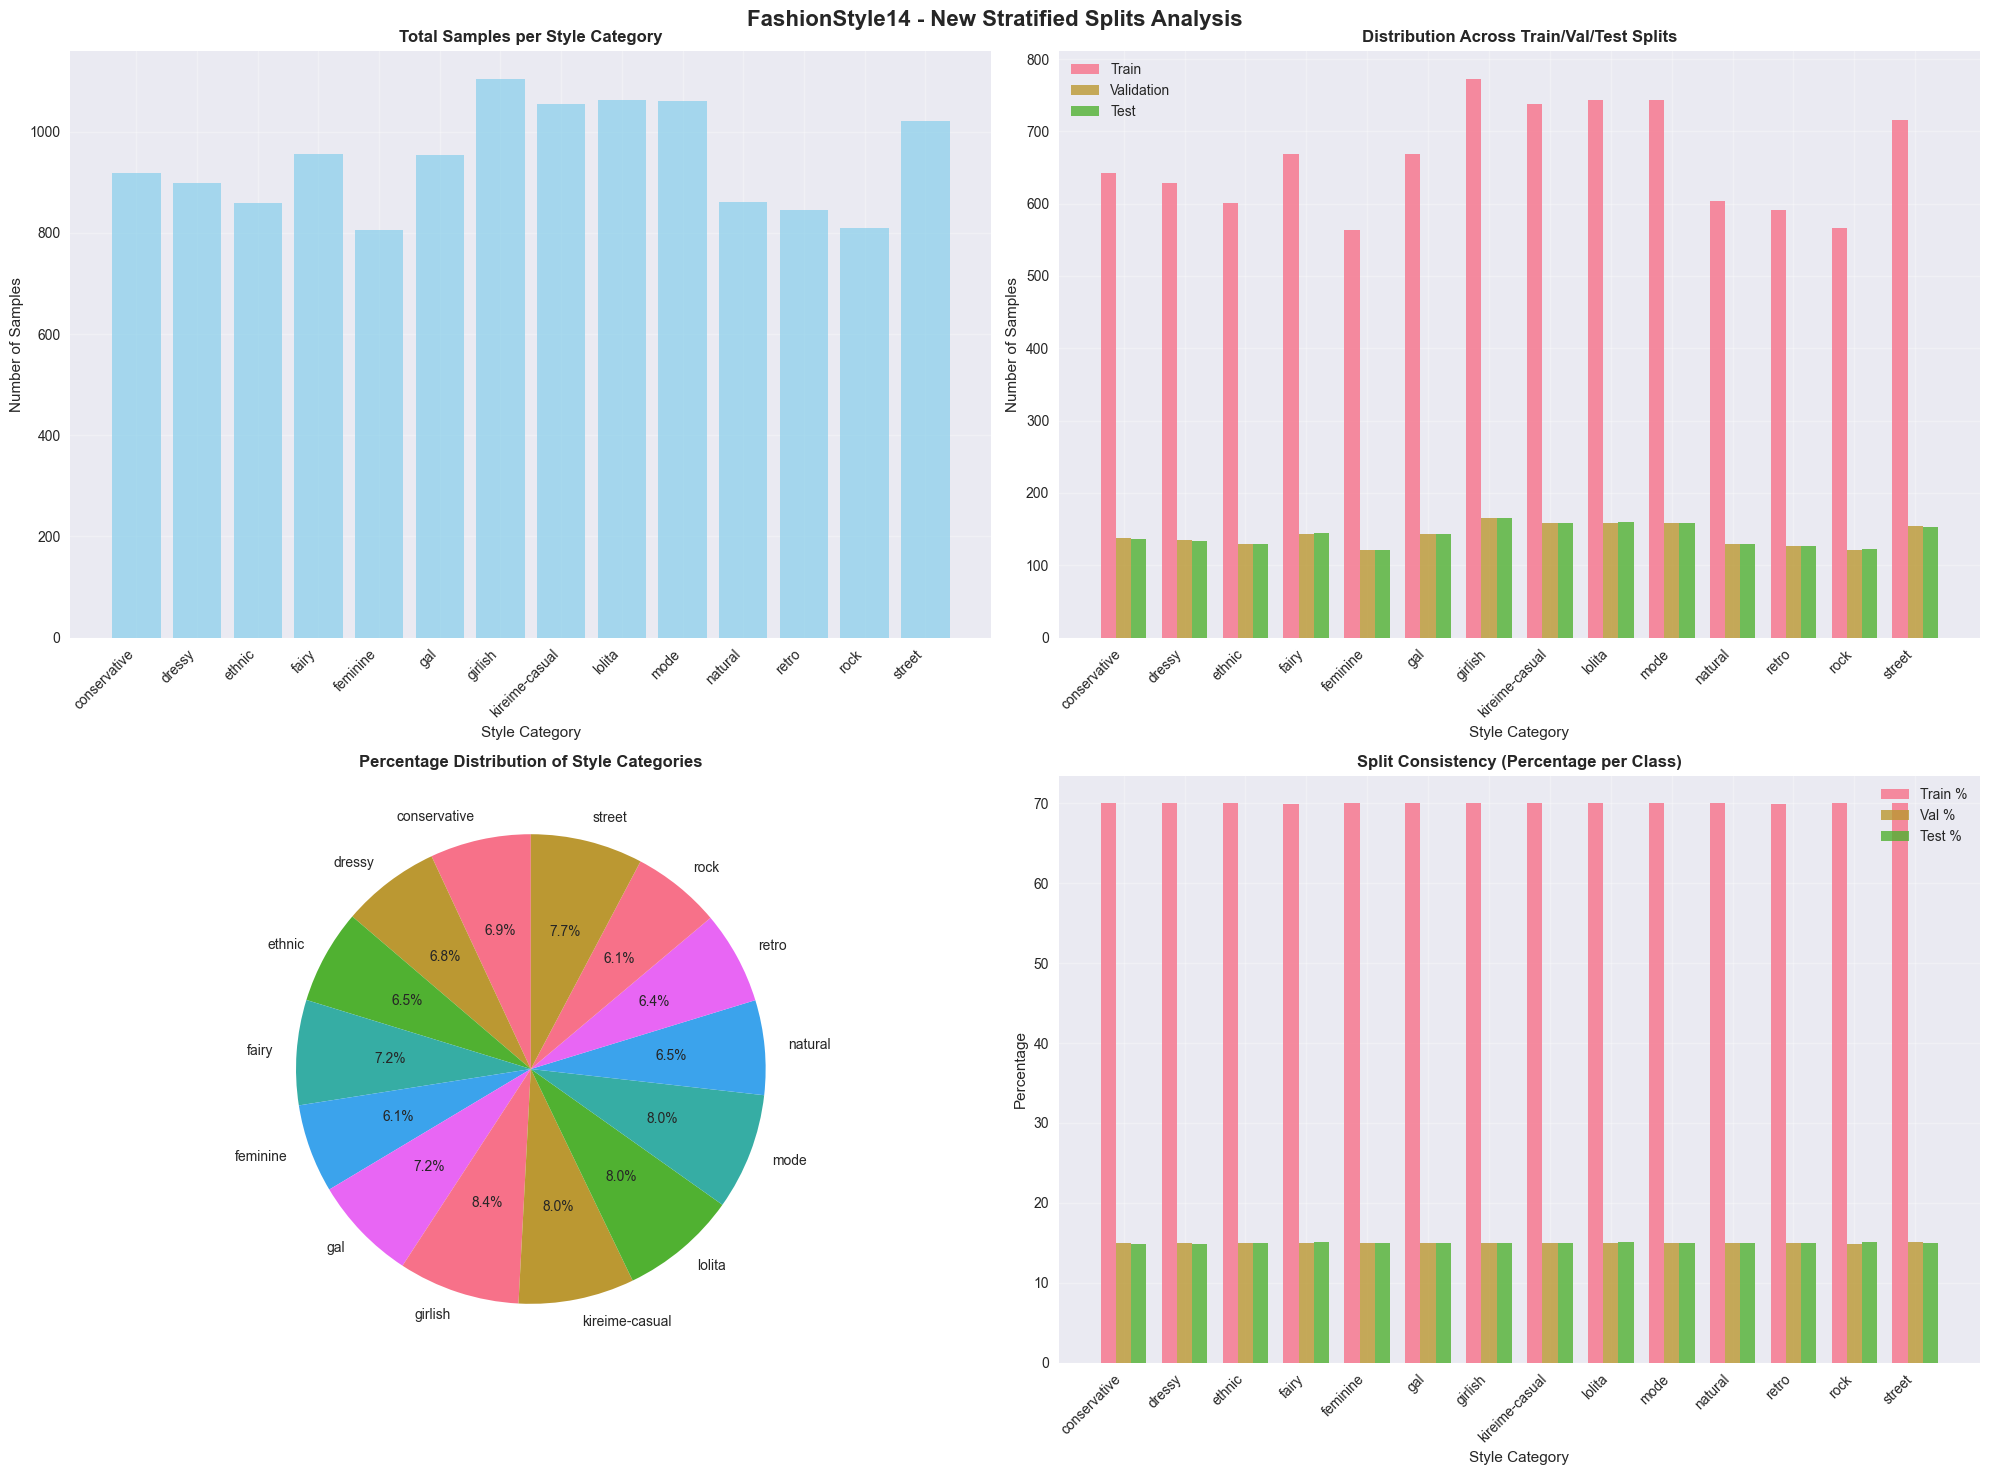

In [13]:
# Visualize the new splits
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('FashionStyle14 - New Stratified Splits Analysis', fontsize=16, fontweight='bold')

# 1. Total distribution comparison
axes[0, 0].bar(range(len(split_analysis)), split_analysis['Total'], color='skyblue', alpha=0.7)
axes[0, 0].set_title('Total Samples per Style Category', fontweight='bold')
axes[0, 0].set_xlabel('Style Category')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_xticks(range(len(split_analysis)))
axes[0, 0].set_xticklabels(split_analysis.index, rotation=45, ha='right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Train/Val/Test comparison
x = np.arange(len(split_analysis))
width = 0.25
axes[0, 1].bar(x - width, split_analysis['Train'], width, label='Train', alpha=0.8)
axes[0, 1].bar(x, split_analysis['Validation'], width, label='Validation', alpha=0.8)
axes[0, 1].bar(x + width, split_analysis['Test'], width, label='Test', alpha=0.8)
axes[0, 1].set_title('Distribution Across Train/Val/Test Splits', fontweight='bold')
axes[0, 1].set_xlabel('Style Category')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(split_analysis.index, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Percentage distribution
axes[1, 0].pie(split_analysis['Total'], labels=split_analysis.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Percentage Distribution of Style Categories', fontweight='bold')

# 4. Split consistency (should be ~70/15/15 for all classes)
split_consistency = split_analysis[['Train_Pct', 'Val_Pct', 'Test_Pct']]
axes[1, 1].bar(x - width, split_consistency['Train_Pct'], width, label='Train %', alpha=0.8)
axes[1, 1].bar(x, split_consistency['Val_Pct'], width, label='Val %', alpha=0.8)
axes[1, 1].bar(x + width, split_consistency['Test_Pct'], width, label='Test %', alpha=0.8)
axes[1, 1].set_title('Split Consistency (Percentage per Class)', fontweight='bold')
axes[1, 1].set_xlabel('Style Category')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(split_analysis.index, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Save New Splits and Generate Class Weights


In [ ]:
# Save the new splits to CSV files
train_df[['image_path']].to_csv('train_new.csv', index=False, header=False)
val_df[['image_path']].to_csv('val_new.csv', index=False, header=False)
test_df[['image_path']].to_csv('test_new.csv', index=False, header=False)

print("New splits saved:")
print(f"  train_new.csv: {len(train_df)} images")
print(f"  val_new.csv: {len(val_df)} images")
print(f"  test_new.csv: {len(test_df)} images")

# Generate class weights for addressing imbalance
def compute_class_weights(df):
    """Compute class weights for handling class imbalance"""
    classes = df['style'].unique()
    class_counts = df['style'].value_counts()
    
    # Compute class weights (inverse frequency)
    class_weights = compute_class_weight(
        'balanced',
        classes=classes,
        y=df['style']
    )
    
    # Create weight dictionary
    weight_dict = dict(zip(classes, class_weights))
    
    return weight_dict, class_counts

# Compute class weights for training
class_weights, class_counts = compute_class_weights(train_df)

print(f"\nClass weights for training (to address imbalance):")
for style, weight in sorted(class_weights.items()):
    count = class_counts[style]
    print(f"  {style}: {weight:.3f} (count: {count})")

# Save class weights to JSON
with open('class_weights.json', 'w') as f:
    json.dump(class_weights, f, indent=2)
print(f"\nClass weights saved to 'class_weights.json'")


New splits saved:
  train_new.csv: 9247 images
  val_new.csv: 1982 images
  test_new.csv: 1982 images

Class weights for training (to address imbalance):
  conservative: 1.027 (count: 643)
  dressy: 1.050 (count: 629)
  ethnic: 1.099 (count: 601)
  fairy: 0.989 (count: 668)
  feminine: 1.171 (count: 564)
  gal: 0.989 (count: 668)
  girlish: 0.854 (count: 773)
  kireime-casual: 0.895 (count: 738)
  lolita: 0.888 (count: 744)
  mode: 0.889 (count: 743)
  natural: 1.095 (count: 603)
  retro: 1.118 (count: 591)
  rock: 1.165 (count: 567)
  street: 0.924 (count: 715)

Class weights saved to 'class_weights.json'


: 